<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
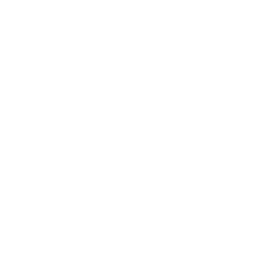
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Building Energy Efficiency Clustering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Sustainability Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This worked example clusters a portfolio of 5,000 commercial buildings by five energy efficiency metrics — Energy Use Intensity (EUI), HVAC efficiency ratio, envelope thermal resistance, lighting power density, and renewable offset percentage — to surface distinct performance tiers for utility rebate targeting. The analysis uses **PROC FASTCLUS** with `REPLACE=FULL` (full seed replacement) and compares k=3, 4, 5, and 6 solutions on overall R-squared, the pseudo-F statistic, and minimum cluster size.

The two fit criteria disagree about the "best" k: overall R-squared rises monotonically with k (0.246 at k=3 to 0.440 at k=6) because adding centroids always explains a little more variance, while the pseudo-F statistic is highest at k=3 (816.0) and falls steadily as k grows. With no statistically dominant elbow, the **k=4 solution** is carried forward as a pragmatic choice — it splits the portfolio into four operationally distinct, sufficiently large tiers (smallest cluster 629 buildings) without over-fragmenting the rebate program. The k=4 solution is then profiled in detail and each cluster is mapped to an actionable efficiency tier.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Annual energy efficiency metrics per building (synthetic) | 5,000 |

The synthetic generator draws each metric independently from a realistic marginal distribution (EUI ~ Normal(85, 35) clipped to 15–250 kBtu/sqft/yr, HVAC COP ~ Normal(3.2, 0.9), envelope R-value ~ Normal(18, 6), lighting power density ~ Normal(1.1, 0.35) W/sqft, and renewable offset ~ 12 × Exponential(1)). Building type and climate region are assigned at random and are **not** correlated with the efficiency metrics — a deliberate design that lets us test whether clustering recovers genuine metric-driven tiers rather than building-type labels.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic building energy metrics
   Commercial building efficiency indicators
   -------------------------------------------------------- */
data work.building_metrics;
    call streaminit(42);
    array btypes[5] $15 _temporary_ ('OFFICE' 'RETAIL' 'WAREHOUSE' 'HOSPITAL' 'SCHOOL');
    array regions[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    do building_id = 1 to 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Energy Use Intensity (kBtu/sqft/yr) */
        eui = round(rand('normal', 85, 35), 0.1);
        if eui < 15 then eui = 15;
        if eui > 250 then eui = 250;

        /* HVAC efficiency ratio (COP equivalent) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        if hvac_efficiency < 1.0 then hvac_efficiency = 1.0;
        if hvac_efficiency > 6.0 then hvac_efficiency = 6.0;

        /* Envelope thermal resistance (R-value) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        if envelope_r_value < 5 then envelope_r_value = 5;
        if envelope_r_value > 40 then envelope_r_value = 40;

        /* Lighting power density (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        if lighting_wpf < 0.3 then lighting_wpf = 0.3;
        if lighting_wpf > 2.5 then lighting_wpf = 2.5;

        /* Renewable energy offset percentage */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        if renewable_pct > 80 then renewable_pct = 80;

        /* Building age in years */
        building_age = int(rand('uniform') * 80) + 1;

        /* Floor area (thousands of sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        if floor_area_ksf > 500 then floor_area_ksf = 500;

        output;
    end;
    drop type_idx reg_idx;
run;

NOTE: DATA work.building_metrics


NOTE: Wrote work.building_metrics (5000 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.67 seconds
  cpu   0.67 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline energy metric distributions by building type
   -------------------------------------------------------- */
proc means data=work.building_metrics n mean std;
    class building_type;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    title 'Energy Metrics by Building Type';
run;

                                            Energy Metrics by Building Type                                             

                                                  The MEANS Procedure

                                                Analysis Variable : eui

        building_type          N Obs           Mean        Std Dev
        ----------------------------------------------------------
        HOSPITAL                1012     84.1666996     34.5981279
        OFFICE                   985     83.4663959     34.8875362
        RETAIL                   971     86.0682801     34.5118904
        SCHOOL                  1066     86.4392120     33.8804108
        WAREHOUSE                966     85.9560041     34.4311866
        ----------------------------------------------------------

                                          Analysis Variable : hvac_efficiency

        building_type          N Obs           Mean        Std Dev
        -------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                            Energy Metrics by Building Type                                             



NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


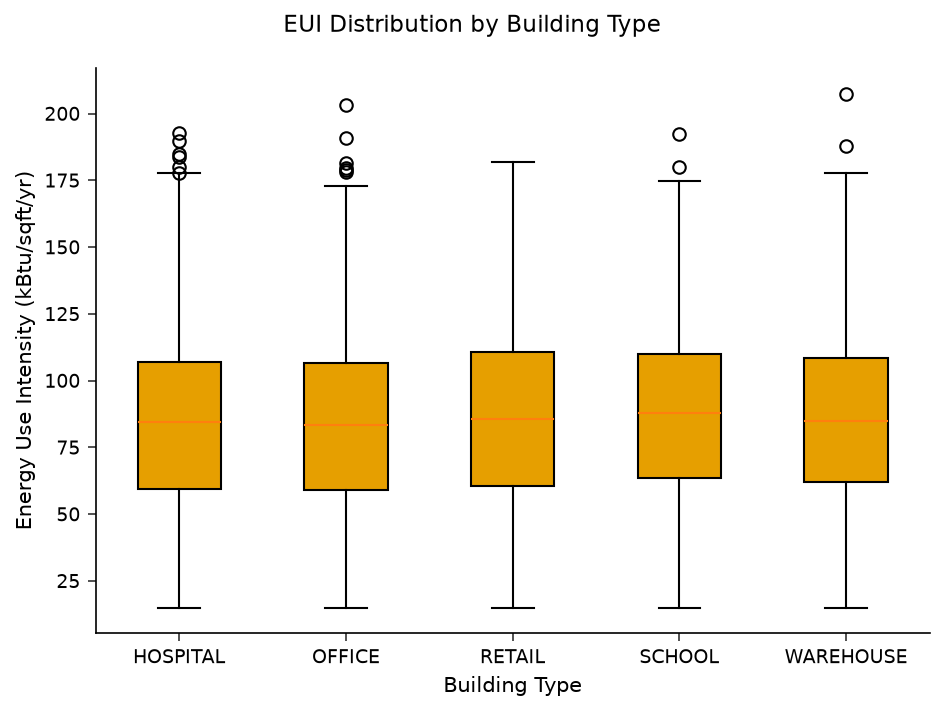

In [3]:
/* --------------------------------------------------------
   EUI distribution by building type
   -------------------------------------------------------- */
proc sgplot data=work.building_metrics;
    vbox eui / category=building_type;
    xaxis label='Building Type';
    yaxis label='Energy Use Intensity (kBtu/sqft/yr)';
    title 'EUI Distribution by Building Type';
run;

---

In [4]:
/* --------------------------------------------------------
   Standardize efficiency metrics
   -------------------------------------------------------- */
proc standard data=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
run;

NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 5000 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   K-means clustering: k=3 with REPLACE=FULL
   -------------------------------------------------------- */
proc fastclus data=work.bldg_std
    maxclusters=3 maxiter=100 converge=0.0001
    replace=full
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    title 'Building Efficiency Clustering: k=3 REPLACE=FULL';
run;

                                            Energy Metrics by Building Type                                             


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                2138         0.8468             4.7820              3         1.6732
2                 774         0.9831             4.4450              3         2.3611
3                2088         0.8447             4.1284              1         1.6732



NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 5000 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   K-means clustering: k=4 with REPLACE=FULL
   -------------------------------------------------------- */
proc fastclus data=work.bldg_std
    maxclusters=4 maxiter=100 converge=0.0001
    replace=full
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    title 'Building Efficiency Clustering: k=4 REPLACE=FULL';
run;

                                            Energy Metrics by Building Type                                             


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                1452         0.8092             3.6790              3         1.8702
2                 629         0.9603             4.2768              3         2.5760
3                1479         0.8059             4.5838              4         1.8619
4

NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 5000 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   K-means clustering: k=5 with REPLACE=FULL
   -------------------------------------------------------- */
proc fastclus data=work.bldg_std
    maxclusters=5 maxiter=100 converge=0.0001
    replace=full
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    title 'Building Efficiency Clustering: k=5 REPLACE=FULL';
run;

                                            Energy Metrics by Building Type                                             


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                1133         0.7716             3.8135              2         1.9748
2                1127         0.7336             3.2444              1         1.9748
3                1089         0.7695             4.3386              5         1.9763
4

NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 5000 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   K-means clustering: k=6 with REPLACE=FULL
   -------------------------------------------------------- */
proc fastclus data=work.bldg_std
    maxclusters=6 maxiter=100 converge=0.0001
    replace=full
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    title 'Building Efficiency Clustering: k=6 REPLACE=FULL';
run;

                                            Energy Metrics by Building Type                                             


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                 910         0.7385             3.5792              2         2.0636
2                 830         0.7244             3.3907              1         2.0636
3                 514         0.9372             4.1331              5         2.8252
4

NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 5000 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Compare cluster quality across k=3-6
   Compute within-cluster R-squared and min cluster size
   -------------------------------------------------------- */
%macro cluster_quality(k);
proc freq data=work.bldg_clust&k noprint;
    tables cluster / out=work.freq_k&k (rename=(count=n_buildings));
run;

proc sql noprint;
    select min(n_buildings) into :min_size_k&k
    from work.freq_k&k;
quit;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                            Energy Metrics by Building Type                                             

                                            Energy Metrics by Building Type                                             

                                            Energy Metrics by Building Type                                             

                                            Energy Metrics by Building Type                                             



NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 774
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 629
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 576
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 514
NOTE: PROC SQL statement used.


                                        Building Efficiency Tier Profiles (k=4)                                         

                                                  The MEANS Procedure

                                                Analysis Variable : eui

                              N
        CLUSTER             Obs           Mean        Std Dev
        -----------------------------------------------------
        1                  1452     71.9113636     27.8518457
        2                   629     81.6783784     32.4178734
        3                  1479    116.7240027     25.2429837
        4                  1440     67.8578472     26.9127594
        -----------------------------------------------------

                                          Analysis Variable : hvac_efficiency

                              N
        CLUSTER             Obs           Mean        Std Dev
        -----------------------------------------------------
        1                  1452 

NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 5000 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 5000 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (5000 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.23 seconds
  cpu   0.23 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 5000 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (5000 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


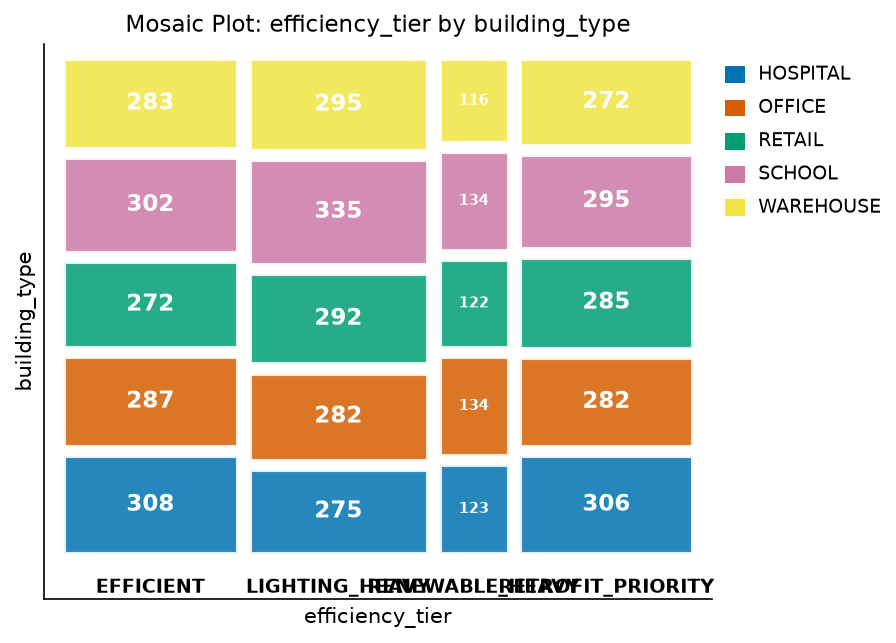

In [10]:
/* --------------------------------------------------------
   Profile the selected k=4 solution
   -------------------------------------------------------- */
data work.bldg_profiled;
    merge work.building_metrics
          work.bldg_clust4 (keep=building_id cluster distance);
    by building_id;
run;

proc means data=work.bldg_profiled mean std;
    class cluster;
    var eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    title 'Building Efficiency Tier Profiles (k=4)';
run;

/* Label efficiency tiers from the observed k=4 centroids:
   Cluster 1 = best HVAC (COP 3.47) + thickest envelope (R 23.7) -> EFFICIENT
   Cluster 2 = by far highest renewable offset (36.0%)           -> RENEWABLE_HEAVY
   Cluster 3 = highest EUI (116.7) + highest lighting (1.27)     -> LIGHTING_HEAVY
   Cluster 4 = weakest HVAC (COP 2.86) + thinnest envelope (R 14.1) -> RETROFIT_PRIORITY */
data work.bldg_tiered;
    set work.bldg_profiled;
    length efficiency_tier $20;
    if cluster = 1 then efficiency_tier = 'EFFICIENT';
    else if cluster = 2 then efficiency_tier = 'RENEWABLE_HEAVY';
    else if cluster = 3 then efficiency_tier = 'LIGHTING_HEAVY';
    else if cluster = 4 then efficiency_tier = 'RETROFIT_PRIORITY';
run;

proc freq data=work.bldg_tiered;
    tables efficiency_tier * building_type / nocol norow;
    title 'Efficiency Tier by Building Type';
run;

---

### Interpretation

With `REPLACE=FULL`, every k value converged cleanly on the full 5,000-building portfolio. The two model-fit criteria pull in opposite directions:

| k | Overall R-squared | Pseudo-F | Smallest cluster |
|---|-------------------|----------|------------------|
| 3 | 0.246 | 816.0 | 774 |
| 4 | 0.328 | 811.2 | 629 |
| 5 | 0.390 | 798.0 | 576 |
| 6 | 0.440 | 786.1 | 514 |

Overall R-squared rises monotonically with k — expected, since each added centroid can only explain more variance — while the pseudo-F statistic is highest at k=3 (816.0) and declines steadily through k=6 (786.1). The absence of a pseudo-F peak beyond k=3 signals that the data has no sharp natural cluster count; the metrics form a fairly continuous cloud rather than tight, well-separated blobs. We therefore select **k=4** on operational rather than purely statistical grounds: four tiers give actionable program granularity, every cluster still holds at least 629 buildings, and the four centroids map onto clearly distinct, interpretable efficiency profiles.

The four k=4 clusters (raw means from the PROC MEANS profile above) separate cleanly:

- **Efficient (Cluster 1, n=1,452):** the best-equipped group — highest HVAC efficiency (COP 3.47) and by far the thickest envelope (R 23.7), with the second-lowest EUI (71.9 kBtu/sqft/yr) and modest renewable offset (8.0%).
- **Renewable-heavy (Cluster 2, n=629):** the small but distinctive on-site-generation group — renewable offset of 36.0%, roughly four times every other tier — with otherwise mid-range metrics (EUI 81.7, COP 3.13).
- **Lighting-heavy (Cluster 3, n=1,479):** the highest absolute consumers (EUI 116.7) driven by the highest lighting power density (1.27 W/sqft), with a mid-range HVAC COP of 3.26 and the second-thinnest envelope (R 16.2).
- **Retrofit priority (Cluster 4, n=1,440):** low EUI on paper (67.9) but the weakest HVAC (COP 2.86), thinnest envelope (R 14.1), lowest lighting load (0.90 W/sqft) and lowest renewable offset (7.8%) — lightly equipped buildings that are the clearest candidates for envelope and HVAC retrofits.

Mean building age is essentially flat across tiers (39.7–40.9 years), confirming the clusters are driven by the efficiency metrics in the VAR list, not by an age proxy.

Because building type was generated independently of the efficiency metrics, the tier-by-building-type cross-tabulation is close to uniform: each of the five building types splits across the four tiers in proportion to its overall share (for example HOSPITAL contributes 308 of the 1,452 efficient buildings, 275 lighting-heavy, 123 renewable-heavy, and 306 retrofit-priority). The clustering recovers metric-driven performance tiers, not building-type labels — exactly the behaviour we want for a rebate program that should target *how a building performs*, not *what it is*. For program design, the 1,440 retrofit-priority and 1,479 lighting-heavy buildings are the natural targets for HVAC/envelope and lighting incentives respectively, while the 629 renewable-heavy buildings — already generating on site — are better suited to demand-reduction than to further generation rebates.

---

In [11]:
/* --------------------------------------------------------
   Export building efficiency tiers and centroid profiles
   -------------------------------------------------------- */
proc export data=work.bldg_tiered
    outfile='building_efficiency_tiers.csv'
    dbms=csv replace;
run;

proc export data=work.bldg_cent4
    outfile='efficiency_tier_centroids.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 5000 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>